# 06 — Weighted linearised inverse calibration

We now use the forward PDE and the regularisation matrix together.

The unknown is the log local variance

$$
u(x,T)=\log\left(\sigma_{\mathrm{loc}}(x,T)^2\right).$$

We start from a reference surface \(u_0\) and write

$$
u=u_0+h,$$

where \(h\) is the correction we want to estimate.

Around the reference surface, the pricing map is approximated by

$$
F(u_0+h)\approx F(u_0)+Lh.
$$

We solve

$$
\min_h
\left\|W(Lh-d)\right\|^2
+
\lambda h^\top Rh,
$$

where

$$
d=y-F(u_0).
$$


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)

Project root: /mnt/data/dupire_audit/dupire_local_vol_project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.synthetic_data import (
    generate_synthetic_option_data,
    save_synthetic_option_data,
)
from src.inverse.linearized_inverse import (
    run_linearized_calibration,
)
from src.inverse.parameterization import (
    local_volatility_from_log_variance,
    reference_log_variance_surface,
)
from src.regularization.operators import (
    build_regularization_matrix,
    regularization_components,
)
from src.regularization.potentials import (
    combine_potentials,
    confidence_potential,
    quote_confidence_surface,
    wing_potential,
)
from src.surfaces.synthetic_surfaces import smile_surface

## 1. Load the synthetic market

We use the same noisy smile quotes created in Stage 3. If the CSV is absent,
the notebook recreates the data using the same random seed.

In [3]:
data_path = (
    project_root
    / "data"
    / "synthetic"
    / "smile_quotes.csv"
)

if data_path.exists():
    synthetic_quotes = pd.read_csv(data_path)
    print("Loaded:", data_path)
else:
    synthetic_quotes = generate_synthetic_option_data(
        surface_function=smile_surface,
        spot=100.0,
        relative_noise=0.005,
        minimum_noise=0.01,
        random_seed=1234,
        number_of_strike_points=201,
        number_of_time_steps=160,
    )
    save_synthetic_option_data(
        synthetic_quotes,
        data_path,
    )
    print("Generated and saved:", data_path)

print("Number of quotes:", len(synthetic_quotes))
synthetic_quotes.head()

Loaded: /mnt/data/dupire_audit/dupire_local_vol_project/data/synthetic/smile_quotes.csv
Number of quotes: 78


,maturity,log_moneyness,forward,strike,true_local_volatility,true_call_price,noise_standard_deviation,noise,observed_call_price,call_lower_bound,call_upper_bound
0,0.1,-0.30,100.0,74.081822,0.229425,25.918212,0.129591,-0.000034,25.918178,25.918178,100.0
1,0.1,-0.25,100.0,77.880078,0.227225,22.120423,0.110602,0.007090,22.127513,22.119922,100.0
2,0.1,-0.20,100.0,81.873075,0.225425,18.132482,0.090662,0.067171,18.199653,18.126925,100.0
3,0.1,-0.15,100.0,86.070798,0.224025,13.973593,0.069868,0.010663,13.984256,13.929202,100.0
4,0.1,-0.10,100.0,90.483742,0.223025,9.768884,0.048844,0.042189,9.811073,9.516258,100.0


## 2. Choose the calibration grid and reference surface

The market contains 78 quotes, but we estimate the correction on a smaller
smooth grid with

$$
5\times9=45
$$

unknown values.

The reference volatility is constant at \(20\%\):

$$
u_0=\log(0.20^2).$$

In [4]:
spot = 100.0
rate = 0.0
dividend_yield = 0.0

calibration_maturities = np.linspace(
    0.10,
    2.00,
    5,
)
calibration_x = np.linspace(
    -0.35,
    0.35,
    9,
)

reference_log_variance = reference_log_variance_surface(
    maturities=calibration_maturities,
    log_moneyness=calibration_x,
    reference_volatility=0.20,
)

reference_volatility = local_volatility_from_log_variance(
    reference_log_variance
)

print("Calibration-surface shape:", reference_log_variance.shape)
print("Number of unknown corrections:", reference_log_variance.size)
print("Reference volatility:", reference_volatility[0, 0])

Calibration-surface shape: (5, 9)
Number of unknown corrections: 45
Reference volatility: 0.2


## 3. Build the potential and regularisation matrix

The regulariser is

$$
R=
\beta I
+
\alpha_xD_x^\top D_x
+
\alpha_TD_T^\top D_T
+
\operatorname{diag}(V).
$$

The potential combines a weak wing penalty and a weak low-confidence penalty.

In [5]:
wing = wing_potential(
    log_moneyness=calibration_x,
    maturities=calibration_maturities,
    strength=0.20,
    power=2.0,
    start=0.20,
)

confidence = quote_confidence_surface(
    log_moneyness=calibration_x,
    maturities=calibration_maturities,
    quote_log_moneyness=synthetic_quotes[
        "log_moneyness"
    ].to_numpy(),
    quote_maturities=synthetic_quotes[
        "maturity"
    ].to_numpy(),
    log_moneyness_bandwidth=0.09,
    maturity_bandwidth=0.30,
)

confidence_penalty = confidence_potential(
    confidence=confidence,
    strength=0.20,
)

combined_potential = combine_potentials(
    wing,
    confidence_penalty,
)

alpha_x = 0.005
alpha_T = 0.002
beta = 1e-4

regularization_matrix, D_x, D_T = (
    build_regularization_matrix(
        number_of_maturities=calibration_maturities.size,
        number_of_log_moneyness_points=calibration_x.size,
        maturity_spacing=(
            calibration_maturities[1]
            - calibration_maturities[0]
        ),
        log_moneyness_spacing=(
            calibration_x[1]
            - calibration_x[0]
        ),
        alpha_x=alpha_x,
        alpha_T=alpha_T,
        beta=beta,
        potential=combined_potential,
    )
)

print("R shape:", regularization_matrix.shape)

R shape: (45, 45)


## 4. Build the Jacobian and solve once

Each Jacobian column measures how all quote prices change when one grid value of
log variance is perturbed:

$$
L_{ij}
\approx
\frac{
F_i(u_0+\varepsilon e_j)-F_i(u_0)
}{\varepsilon}.
$$

This is the slowest cell because it calls the PDE once for every unknown grid
value.

The quote weights are

$$
W_{ii}=\frac{1}{s_i},
$$

where \(s_i\) is the quote-noise standard deviation.

In [6]:
regularization_strength = 1000.0

linearized_result = run_linearized_calibration(
    reference_log_variance=reference_log_variance,
    calibration_maturities=calibration_maturities,
    calibration_log_moneyness=calibration_x,
    quote_data=synthetic_quotes,
    regularization_matrix=regularization_matrix,
    regularization_strength=regularization_strength,
    spot=spot,
    rate=rate,
    dividend_yield=dividend_yield,
    finite_difference_step=1e-3,
    jacobian_scheme="forward",
    number_of_strike_points=151,
    number_of_time_steps=120,
    verbose=True,
)

print("\nReference weighted RMSE:",
      f"{linearized_result['reference_weighted_rmse']:.6f}")
print("Linearised weighted RMSE:",
      f"{linearized_result['linearized_weighted_rmse']:.6f}")
print("Nonlinear reprice weighted RMSE:",
      f"{linearized_result['nonlinear_weighted_rmse']:.6f}")

Jacobian columns completed: 4/45
Jacobian columns completed: 8/45


Jacobian columns completed: 12/45
Jacobian columns completed: 16/45


Jacobian columns completed: 20/45
Jacobian columns completed: 24/45


Jacobian columns completed: 28/45
Jacobian columns completed: 32/45


Jacobian columns completed: 36/45
Jacobian columns completed: 40/45


Jacobian columns completed: 44/45
Jacobian columns completed: 45/45

Reference weighted RMSE: 13.719441
Linearised weighted RMSE: 1.166539
Nonlinear reprice weighted RMSE: 1.603869


## 5. Why the linearised and nonlinear price errors differ

The linear solve uses

$$
F(u_0+h)\approx F(u_0)+Lh.
$$

The `linearised weighted RMSE` is measured using the right-hand side of this
approximation.

The `nonlinear reprice weighted RMSE` runs the full PDE again at \(u_0+h\).
They need not be identical because the forward map is nonlinear. The nonlinear
error should still be much smaller than the reference error.

## 6. Inspect the singular values of the weighted Jacobian

If the singular values decay strongly, some directions in the surface produce
very little observable change in option prices. Those directions are difficult
to estimate from data alone.

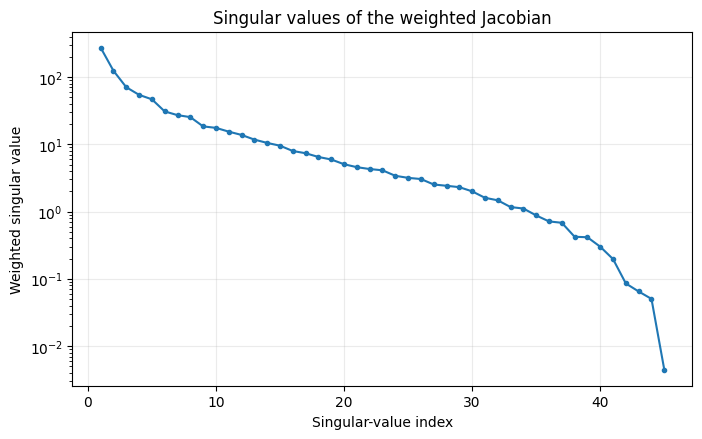

Largest singular value: 273.53986754678823
Smallest singular value: 0.00448016952931491
Singular-value ratio: 61055.69571797362


In [7]:
singular_values = linearized_result[
    "singular_values"
]

plt.figure(figsize=(8, 4.6))
plt.semilogy(
    np.arange(1, singular_values.size + 1),
    singular_values,
    marker="o",
    markersize=3,
)
plt.xlabel("Singular-value index")
plt.ylabel("Weighted singular value")
plt.title("Singular values of the weighted Jacobian")
plt.grid(alpha=0.25)
plt.show()

print("Largest singular value:", singular_values[0])
print("Smallest singular value:", singular_values[-1])
print(
    "Singular-value ratio:",
    singular_values[0] / singular_values[-1],
)

## 7. Reference, correction, estimate, and truth

The correction is added in log-variance space:

$$
\widehat u=u_0+\widehat h.
$$

The corresponding volatility is

$$
\widehat\sigma=\exp\left(\frac{\widehat u}{2}\right).
$$

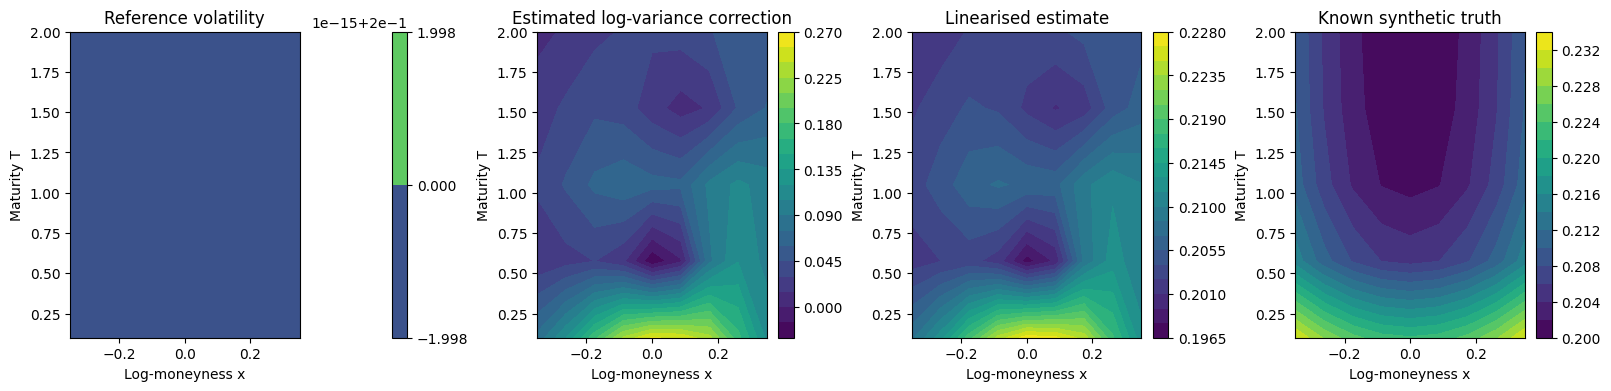

In [8]:
correction_surface = linearized_result[
    "correction_surface"
]
estimated_log_variance = linearized_result[
    "estimated_log_variance"
]
estimated_volatility = local_volatility_from_log_variance(
    estimated_log_variance
)

x_mesh, maturity_mesh = np.meshgrid(
    calibration_x,
    calibration_maturities,
)
true_volatility = smile_surface(
    x_mesh,
    maturity_mesh,
)

figure, axes = plt.subplots(
    1,
    4,
    figsize=(16, 3.8),
    constrained_layout=True,
)

surfaces = [
    (reference_volatility, "Reference volatility"),
    (correction_surface, "Estimated log-variance correction"),
    (estimated_volatility, "Linearised estimate"),
    (true_volatility, "Known synthetic truth"),
]

for axis, (surface, title) in zip(axes, surfaces):
    contour = axis.contourf(
        calibration_x,
        calibration_maturities,
        surface,
        levels=20,
    )
    figure.colorbar(contour, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("Log-moneyness x")
    axis.set_ylabel("Maturity T")

plt.show()

## 8. Surface recovery error

Because the data are synthetic, we can compare the estimated surface with the
actual surface used to generate the prices.

In [9]:
reference_surface_rmse = np.sqrt(
    np.mean(
        (reference_volatility - true_volatility) ** 2
    )
)

estimated_surface_rmse = np.sqrt(
    np.mean(
        (estimated_volatility - true_volatility) ** 2
    )
)

print(
    "Reference-surface RMSE:",
    f"{reference_surface_rmse:.6f}",
)
print(
    "Estimated-surface RMSE:",
    f"{estimated_surface_rmse:.6f}",
)

assert (
    estimated_surface_rmse
    < reference_surface_rmse
)

Reference-surface RMSE: 0.013495
Estimated-surface RMSE: 0.007092


## 9. Inspect the penalty contributions

This separates the magnitude, log-moneyness roughness, maturity roughness, and
potential terms for the estimated correction.

In [10]:
penalty_components = regularization_components(
    correction=correction_surface,
    D_x=D_x,
    D_T=D_T,
    alpha_x=alpha_x,
    alpha_T=alpha_T,
    beta=beta,
    potential=combined_potential,
)

for name, value in penalty_components.items():
    print(f"{name:16s}: {value:.6f}")

magnitude       : 0.000044
x_roughness     : 0.020493
time_roughness  : 0.002527
potential       : 0.027268
total           : 0.050332


## 10. Compare fitted prices with observations

The reference prices come from the constant \(20\%\) surface. The fitted prices
come from a full nonlinear PDE reprice at the estimated surface.

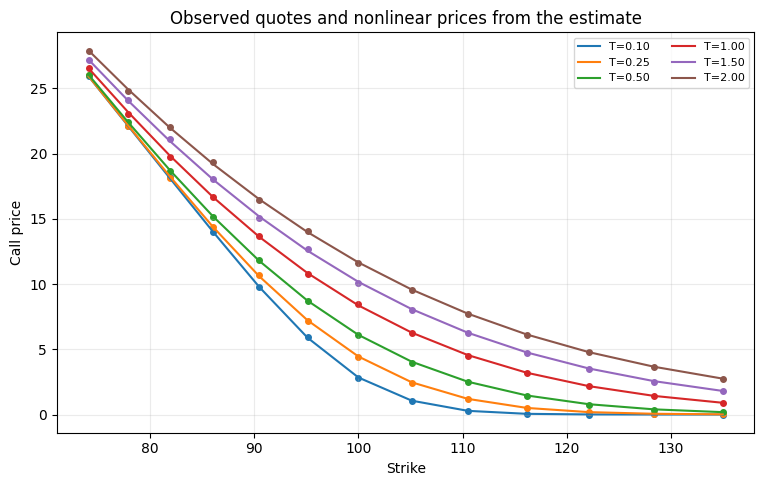

In [11]:
price_comparison = synthetic_quotes[
    [
        "maturity",
        "strike",
        "observed_call_price",
        "true_call_price",
    ]
].copy()

price_comparison["reference_price"] = (
    linearized_result["reference_prices"]
)
price_comparison["fitted_price"] = (
    linearized_result["nonlinear_prices"]
)

plt.figure(figsize=(9, 5.2))

for maturity in np.sort(
    price_comparison["maturity"].unique()
):
    maturity_data = price_comparison[
        np.isclose(
            price_comparison["maturity"],
            maturity,
        )
    ].sort_values("strike")

    plt.scatter(
        maturity_data["strike"],
        maturity_data["observed_call_price"],
        s=16,
    )
    plt.plot(
        maturity_data["strike"],
        maturity_data["fitted_price"],
        label=f"T={maturity:.2f}",
    )

plt.xlabel("Strike")
plt.ylabel("Call price")
plt.title("Observed quotes and nonlinear prices from the estimate")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.25)
plt.show()

## 11. Save the Stage 6 result

The saved file contains the calibration grid, Jacobian, reference surface,
correction, estimate, and fitted prices. Stage 7 can use this estimate as the
starting point for nonlinear Gauss–Newton calibration.

In [12]:
output_directory = (
    project_root
    / "outputs"
    / "stage_06"
)
output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

output_path = (
    output_directory
    / "linearized_calibration.npz"
)

np.savez_compressed(
    output_path,
    calibration_maturities=calibration_maturities,
    calibration_x=calibration_x,
    reference_log_variance=reference_log_variance,
    correction_surface=correction_surface,
    estimated_log_variance=estimated_log_variance,
    jacobian=linearized_result["jacobian"],
    singular_values=singular_values,
    reference_prices=linearized_result["reference_prices"],
    fitted_prices=linearized_result["nonlinear_prices"],
    regularization_strength=regularization_strength,
)

print("Saved Stage 6 result to:")
print(output_path)

Saved Stage 6 result to:
/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_06/linearized_calibration.npz


## Stage 6 result

We have completed one weighted, regularised, linearised inverse solve:

$$
\widehat h
=
\left(
L^\top W^\top WL
+
\lambda R
\right)^{-1}
L^\top W^\top Wd.
$$

This produced a smooth correction, improved the option-price fit, and improved
the volatility surface relative to the constant reference.

The next stage will repeat the linearisation around updated surfaces, producing
the nonlinear Gauss–Newton calibration.